# NB-6: Reinforcement Learning for Battery Energy Arbitrage

This notebook trains and evaluates two RL algorithms (DQN and PPO) for battery energy arbitrage,
and compares them against a rule-based baseline.

**Pipeline:**
1. Load electricity demand data (proxy for price)
2. Run rule-based baseline (moving average heuristic)
3. Train DQN agent (with baseline experience pre-fill)
4. Train PPO agent (best of 3 runs)
5. Evaluate all three on the test set
6. Generate comparison graphs

**Key design choices:**
- Episodes use random 6-month (4320h) windows from the training data to prevent overfitting
- State includes a 6-hour price trend feature, giving RL an edge over the backward-looking baseline
- DQN replay buffer is pre-filled with baseline experience (imitation learning bootstrap)
- PPO is trained 3 times and the best model is kept (due to run-to-run variance)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from data_loader import load_prices
from BatteryMDP import BatteryMDP
from baseline import run_baseline
from dqn_agent import DQNAgent, train_dqn, evaluate_dqn
from ppo_agent import PPOAgent, train_ppo, evaluate_ppo

COLOURS = {'Baseline': '#888888', 'DQN': '#1f77b4', 'PPO': '#ff7f0e'}

## 1. Load Data

In [21]:
train_prices = load_prices('train')
test_prices = load_prices('test')

print(f'Training data: {len(train_prices):,} hours ({len(train_prices)//24:,} days)')
print(f'Test data:     {len(test_prices):,} hours ({len(test_prices)//24:,} days)')
print(f'Train demand range: {train_prices.min():.0f} - {train_prices.max():.0f} MWh')
print(f'Test demand range:  {test_prices.min():.0f} - {test_prices.max():.0f} MWh')

Training data: 59,647 hours (2,485 days)
Test data:     12,782 hours (532 days)
Train demand range: 321 - 32666 MWh
Test demand range:  39 - 29545 MWh


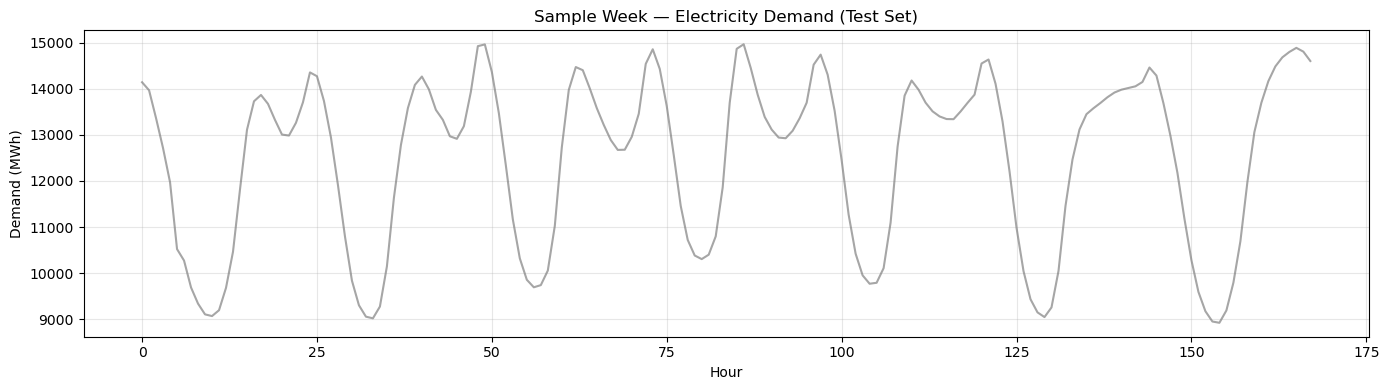

In [22]:
# Visualise a sample week of demand data
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_prices[:168], color='gray', alpha=0.7)
ax.set_xlabel('Hour')
ax.set_ylabel('Demand (MWh)')
ax.set_title('Sample Week — Electricity Demand (Test Set)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Rule-Based Baseline

In [23]:
# Test different moving average windows
for w in [12, 24, 48, 72]:
    result = run_baseline(test_prices, window=w)
    print(f'Window {w:3d}h: profit = ${result["total_profit"]:,.0f}')

# Use the best (24h)
baseline_result = run_baseline(test_prices, window=24)
print(f'\nBaseline profit (24h window): ${baseline_result["total_profit"]:,.0f}')

Window  12h: profit = $239,249,568
Window  24h: profit = $294,091,680
Window  48h: profit = $284,239,168
Window  72h: profit = $277,989,344

Baseline profit (24h window): $294,091,680


## 3. Train DQN Agent

In [24]:
%%time
dqn_agent, dqn_rewards = train_dqn(train_prices, num_episodes=1500, log_every=300, use_baseline_prefill=True)

Pre-filled buffer with 50000 baseline transitions, ran 1000 updates
Episode 300/1500  |  Avg Reward: 18,015,086  |  Epsilon: 0.383
Episode 600/1500  |  Avg Reward: 71,437,448  |  Epsilon: 0.050
Episode 900/1500  |  Avg Reward: 75,960,664  |  Epsilon: 0.050
Episode 1200/1500  |  Avg Reward: 78,091,904  |  Epsilon: 0.050
Episode 1500/1500  |  Avg Reward: 78,704,776  |  Epsilon: 0.050
CPU times: user 20min 4s, sys: 49.6 s, total: 20min 54s
Wall time: 20min 51s


In [25]:
dqn_agent.save('models/dqn_battery.pt')

dqn_result = evaluate_dqn(dqn_agent, test_prices)
print(f'DQN Test Profit: ${dqn_result["total_profit"]:,.0f}')

DQN Test Profit: $229,973,904


## 4. Train PPO Agent

In [26]:
%%time
# Train PPO 5 times and keep the best model (due to run-to-run variance)
best_ppo_profit = -np.inf
best_ppo_agent = None
all_ppo_rewards = []

for run in range(5):
    agent, rewards = train_ppo(train_prices, num_episodes=1500, log_every=1500)
    result = evaluate_ppo(agent, test_prices)
    profit = result['total_profit']
    print(f'PPO run {run+1}/5: ${profit:,.0f}')
    all_ppo_rewards.append(rewards)
    if profit > best_ppo_profit:
        best_ppo_profit = profit
        best_ppo_agent = agent
        best_ppo_rewards = rewards

ppo_agent = best_ppo_agent
ppo_rewards = best_ppo_rewards
print(f'\nBest PPO: ${best_ppo_profit:,.0f}')

Episode 1500/1500  |  Avg Reward: 87,390,400
PPO run 1/5: $282,409,920
Episode 1500/1500  |  Avg Reward: 87,447,088
PPO run 2/5: $294,827,680
Episode 1500/1500  |  Avg Reward: 87,258,992
PPO run 3/5: $265,636,032
Episode 1500/1500  |  Avg Reward: 87,121,256
PPO run 4/5: $264,601,792
Episode 1500/1500  |  Avg Reward: 86,604,192
PPO run 5/5: $281,914,368

Best PPO: $294,827,680
CPU times: user 2h 20min 28s, sys: 5min 39s, total: 2h 26min 7s
Wall time: 2h 26min 39s


In [27]:
ppo_agent.save('models/ppo_battery.pt')

ppo_result = evaluate_ppo(ppo_agent, test_prices)
print(f'PPO Test Profit: ${ppo_result["total_profit"]:,.0f}')

PPO Test Profit: $294,827,680


## 5. Results Comparison

In [28]:
results = {
    'Baseline': baseline_result,
    'DQN': dqn_result,
    'PPO': ppo_result,
}

baseline_profit = baseline_result['total_profit']

print(f"{'Strategy':<12} {'Total Profit ($)':>18} {'vs Baseline':>14}")
print('-' * 48)
for label, res in results.items():
    profit = res['total_profit']
    if label == 'Baseline':
        imp = '\u2014'
    else:
        pct = (profit - baseline_profit) / abs(baseline_profit) * 100
        imp = f'{pct:+.1f}%'
    print(f'{label:<12} {profit:>18,.0f} {imp:>14}')

Strategy       Total Profit ($)    vs Baseline
------------------------------------------------
Baseline            294,091,680              —
DQN                 229,973,904         -21.8%
PPO                 294,827,680          +0.3%


## 6. Graphs

### 6.1 Learning Curves

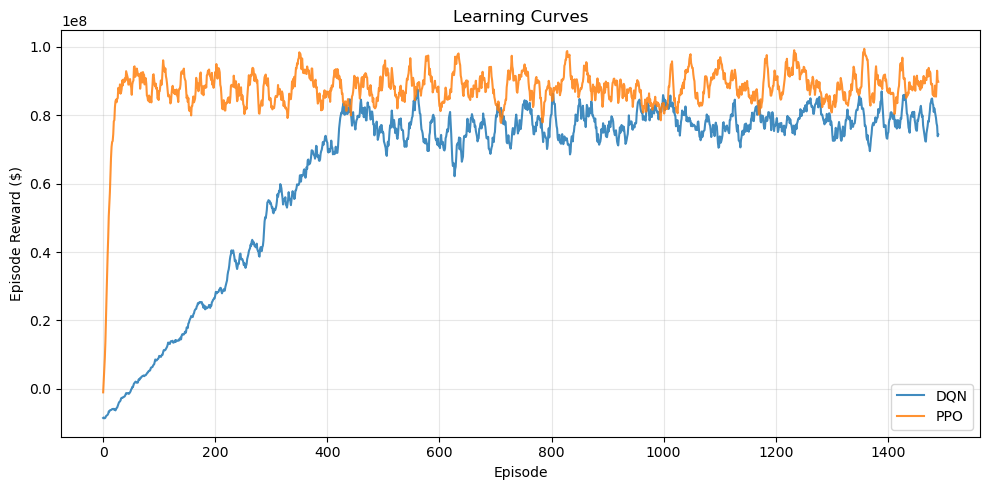

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
window = 10
for label, rewards, colour in [('DQN', dqn_rewards, COLOURS['DQN']),
                                 ('PPO', ppo_rewards, COLOURS['PPO'])]:
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax.plot(smoothed, label=label, color=colour, alpha=0.85)
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Reward ($)')
ax.set_title('Learning Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Cumulative Profit — Test Set

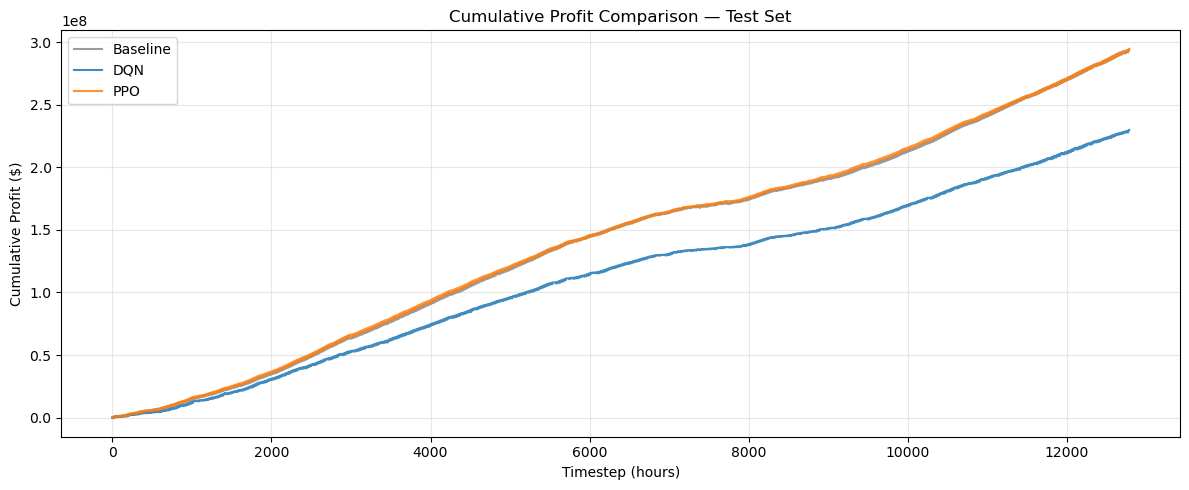

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, res in results.items():
    ax.plot(res['cumulative_profits'], label=label, color=COLOURS[label], alpha=0.85)
ax.set_xlabel('Timestep (hours)')
ax.set_ylabel('Cumulative Profit ($)')
ax.set_title('Cumulative Profit Comparison — Test Set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/cumulative_profit.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Battery State-of-Charge — Sample Week

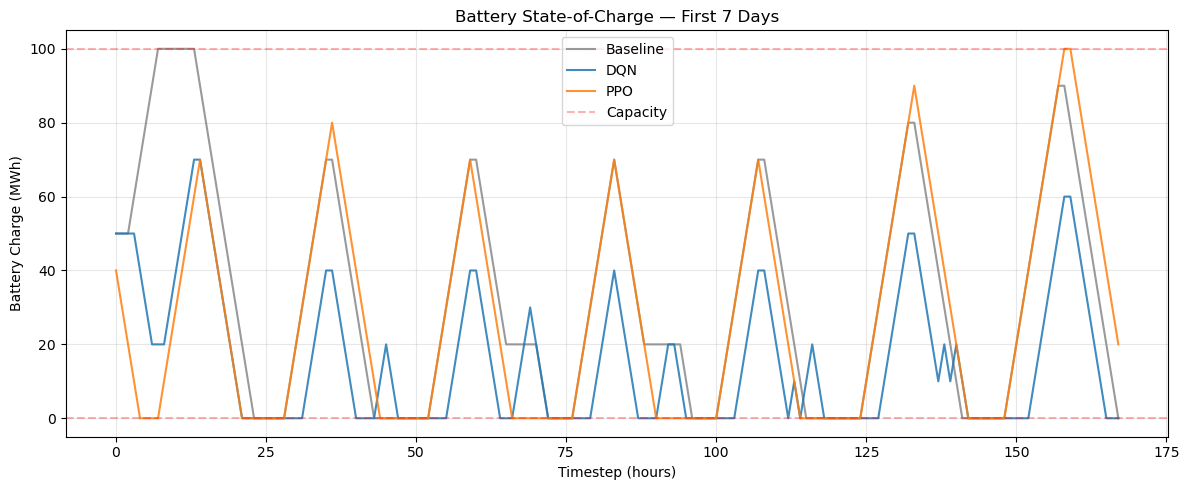

In [31]:
sample_hours = 168  # 1 week
fig, ax = plt.subplots(figsize=(12, 5))
for label, res in results.items():
    ax.plot(res['charges'][:sample_hours], label=label, color=COLOURS[label], alpha=0.85)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.3, label='Capacity')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Timestep (hours)')
ax.set_ylabel('Battery Charge (MWh)')
ax.set_title(f'Battery State-of-Charge — First {sample_hours // 24} Days')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/battery_soc.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Price / Actions Overlay — DQN

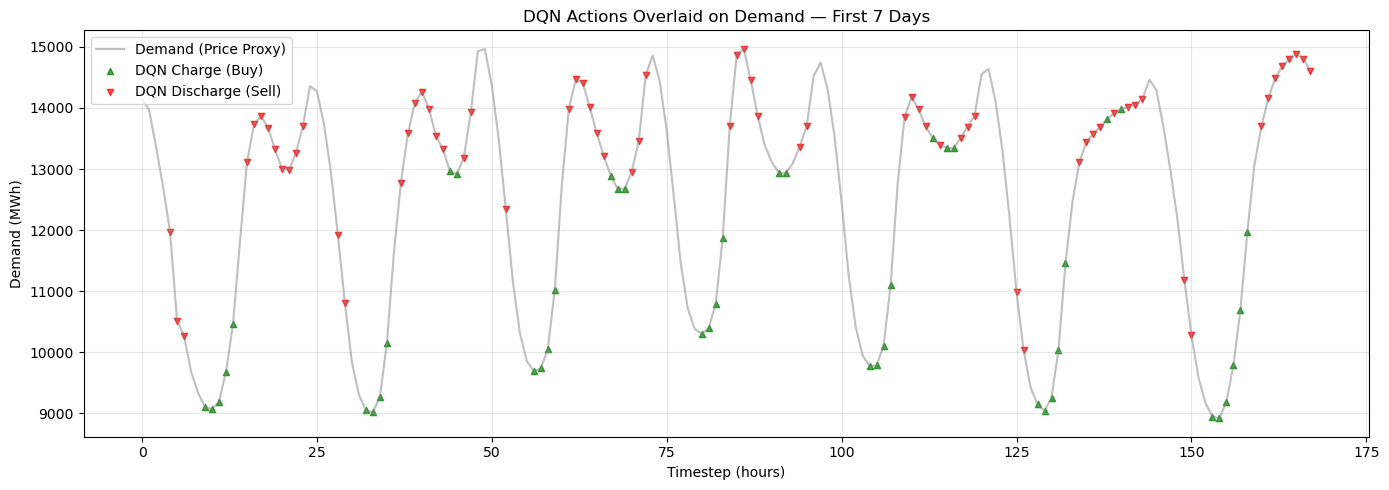

In [32]:
sample_hours = 168
fig, ax = plt.subplots(figsize=(14, 5))

prices = test_prices[:sample_hours]
ax.plot(prices, color='gray', alpha=0.5, label='Demand (Price Proxy)')

dqn_actions = dqn_result['actions'][:sample_hours]
t = np.arange(sample_hours)

charge_mask = dqn_actions == BatteryMDP.CHARGE
discharge_mask = dqn_actions == BatteryMDP.DISCHARGE

ax.scatter(t[charge_mask], prices[charge_mask],
           c='green', marker='^', s=20, alpha=0.7, label='DQN Charge (Buy)')
ax.scatter(t[discharge_mask], prices[discharge_mask],
           c='red', marker='v', s=20, alpha=0.7, label='DQN Discharge (Sell)')

ax.set_xlabel('Timestep (hours)')
ax.set_ylabel('Demand (MWh)')
ax.set_title(f'DQN Actions Overlaid on Demand — First {sample_hours // 24} Days')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/price_actions_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Action Distribution

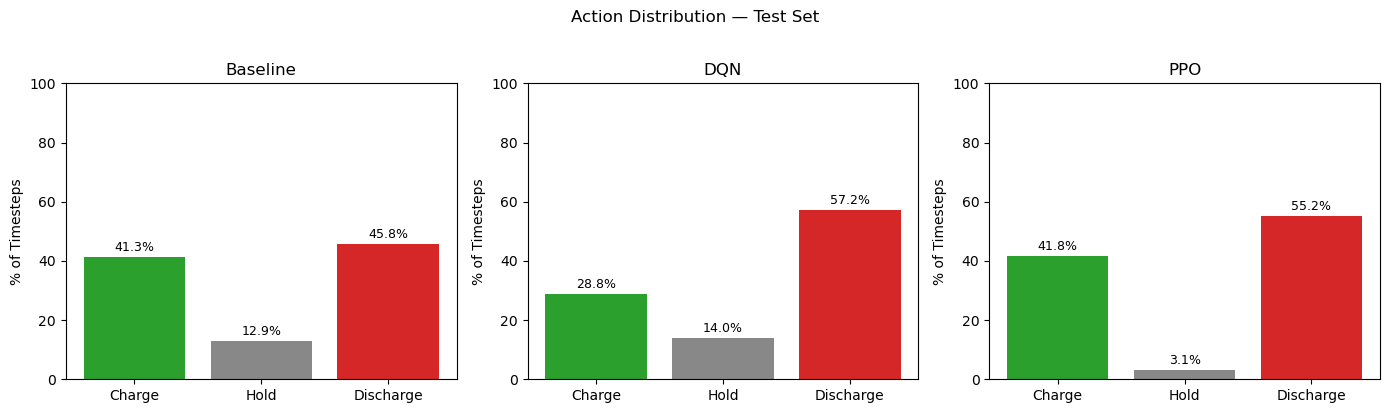

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
action_labels = ['Charge', 'Hold', 'Discharge']
bar_colours = ['#2ca02c', '#888888', '#d62728']

for ax, (label, res) in zip(axes, results.items()):
    counts = [np.sum(res['actions'] == i) for i in range(3)]
    total = sum(counts)
    pcts = [c / total * 100 for c in counts]
    ax.bar(action_labels, pcts, color=bar_colours)
    ax.set_title(label)
    ax.set_ylabel('% of Timesteps')
    ax.set_ylim(0, 100)
    for i, (c, p) in enumerate(zip(counts, pcts)):
        ax.text(i, p + 2, f'{p:.1f}%', ha='center', fontsize=9)

plt.suptitle('Action Distribution — Test Set', y=1.02)
plt.tight_layout()
plt.savefig('figures/action_distribution.png', dpi=150, bbox_inches='tight')
plt.show()